<a href="https://colab.research.google.com/github/ShoaibAhmed96/mac246-labs/blob/main/lab1/MAC246_LAB1_S02_Control_Classification_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAC 246 Graded Lab 1, Sessions 2 and 3: classifying security controls

**Wednesday, September 16 and Wednesday, September 23, 2026.**

This notebook uses the Python standard library plus pandas and matplotlib, needs no root, no
socket and no Kali tool, and contacts nothing, so it runs the same in Google Colab in a browser
and in Python 3 on the Kali image in B124. In Colab pandas and matplotlib are already there. On
the Kali image, if an import fails, install them once with
`pip install --break-system-packages pandas matplotlib`.

**Nothing in this notebook contacts any host outside it.** The data it works on is the eight
controls written into the notebook itself.

Sessions 2 and 3 make one deliverable together. Session 2 classifies the controls and builds the
summary. Session 3 finishes the write-up, the reflection paragraph and the final commit.


## Section 1. Your personalization token

A new token each session. Put your own student ID in `sid` and run the cell.


In [7]:
import hashlib, datetime, pathlib

sid = '24364498'
stamp = datetime.datetime.now().strftime('%Y%m%d-%H%M')
token = hashlib.sha256((sid + '-' + stamp).encode()).hexdigest()[:16]
pathlib.Path('lab_token.txt').write_text(token)
print('MAC246 Lab 1 token:', token)


MAC246 Lab 1 token: a030354807256b6b


## Section 2. The two questions you ask about any control

A control has a **category**, which is about who or what carries it out, and a **function**,
which is about when in an incident it acts. They are independent: a technical control can be
preventive or detective, and so can a physical one.

Use these rules. They are the ones the Security+ SY0-701 objective 1.1 lists use, and they give
exactly one defensible answer for each of the eight controls below.

**Category, who or what carries it out**

| Category | It is carried out by |
|---|---|
| `technical` | a system, enforced in software or hardware without a person in the loop |
| `managerial` | a decision: a policy, a plan, an assessment, a documented process |
| `operational` | a person, doing something on a schedule or as part of a job |
| `physical` | something in the built environment acting on people and things: a fence, a lock, a camera, a sign, a guard |

**Function, when it acts**

| Function | It acts |
|---|---|
| `deterrent` | before, by discouraging someone from trying |
| `preventive` | before, by blocking the attempt outright |
| `detective` | during or after, by noticing that something happened |
| `corrective` | after, by restoring or repairing what was lost |
| `compensating` | in place of a control you cannot deploy, covering the same ground less directly |
| `directive` | by instructing people what they are required to do |


In [8]:
CONTROLS = {
    'C1': 'Multi-factor authentication required for administrator logins.',
    'C2': 'Nightly encrypted backups written to an off-site facility.',
    'C3': 'A monthly security-awareness email telling staff how to report a suspicious '
          'message.',
    'C4': 'A written incident-response plan, approved and kept current.',
    'C5': 'A perimeter firewall between the campus network and the Internet.',
    'C6': 'A camera recording the server-room door.',
    'C7': 'A sign at the gate reading: this area is under video surveillance.',
    'C8': 'A supervisor reviewing privileged-access logs by hand every Friday, because the '
          'campus cannot afford the security monitoring platform it wanted.',
}

CATEGORIES = ('technical', 'managerial', 'operational', 'physical')
FUNCTIONS  = ('deterrent', 'preventive', 'detective', 'corrective',
              'compensating', 'directive')

for k in sorted(CONTROLS):
    print(k, '|', CONTROLS[k])


C1 | Multi-factor authentication required for administrator logins.
C2 | Nightly encrypted backups written to an off-site facility.
C3 | A monthly security-awareness email telling staff how to report a suspicious message.
C4 | A written incident-response plan, approved and kept current.
C5 | A perimeter firewall between the campus network and the Internet.
C6 | A camera recording the server-room door.
C7 | A sign at the gate reading: this area is under video surveillance.
C8 | A supervisor reviewing privileged-access logs by hand every Friday, because the campus cannot afford the security monitoring platform it wanted.


### Your classification

Fill in a category and a function for each control, one word from the lists above in each slot.
Leave a slot empty if you are not ready to commit to it; the check cell lists what is still open
rather than failing you for it.

Read C8's wording twice before you place it. The reason the campus is doing it by hand is the
whole answer.


In [9]:
my_calls = {
    #       category        function
    'C1': ('technical',              'preventive'),
    'C2': ('technical',              'corrective'),
    'C3': ('operational',              'directive'),
    'C4': ('managerial',              'directive'),
    'C5': ('technical',              'preventive'),
    'C6': ('physical',              'detective'),
    'C7': ('physical',              'deterrent'),
    'C8': ('operational',              'compensating'),
}

done = sum(1 for c, f in my_calls.values() if c.strip() and f.strip())
print('fully classified:', done, 'of', len(my_calls))


fully classified: 8 of 8


## Section 3. Check your work

The cell below checks a digest of each call rather than the call itself, so it can tell you
whether you are right without telling you the answer. Do not edit the digests to make a check
pass. If a call is rejected, the call is wrong, not the check.

Screenshot the output of this cell as `lab1_s02_checks.png`.


In [11]:
import hashlib

DIGESTS = {
    'C1': ('465b15a31652', '82717d5492b5'),
    'C2': ('6623d54570f2', 'f8e019626ff7'),
    'C3': ('71957fddc46c', '3ae57197c7e8'),
    'C4': ('c51b7954f451', '541dea9d5bca'),
    'C5': ('c9220b763269', '52c8a1301a6b'),
    'C6': ('93f215203143', 'dfb368ec56f3'),
    'C7': ('318987787fcd', 'afbf36da1058'),
    'C8': ('8e07c4db85bc', '8b8041ef418b'),
}

def _digest(key, field, value):
    return hashlib.sha256(
        ('mac246-lab1-s02:' + key + ':' + field + ':' + value.strip().lower()).encode()
    ).hexdigest()[:12]

assert len(CONTROLS) == 8, 'there are eight controls to place'
assert set(my_calls) == set(CONTROLS), 'my_calls must have one entry per control'
print('CHECK PASS: eight controls, eight pairs to fill.')

bad = [k for k, (c, f) in my_calls.items()
       if (c.strip() and c.strip().lower() not in CATEGORIES)
       or (f.strip() and f.strip().lower() not in FUNCTIONS)]
assert not bad, f'use only the words in the two tables; fix {bad}'
print('CHECK PASS: every word you used is a real category or function.')

wrong = []
for k, (c, f) in my_calls.items():
    if c.strip() and _digest(k, 'category', c) != DIGESTS[k][0]:
        wrong.append(k + ' category')
    if f.strip() and _digest(k, 'function', f) != DIGESTS[k][1]:
        wrong.append(k + ' function')
assert not wrong, f'these are not right yet: {wrong}'

todo = sorted(k for k, (c, f) in my_calls.items() if not (c.strip() and f.strip()))
if todo:
    print('STILL TO DO:', todo)
else:
    print('CHECK PASS: all eight controls are placed correctly.')

assert token, 'run the token cell first'
print('CHECK PASS: token present:', token)


CHECK PASS: eight controls, eight pairs to fill.
CHECK PASS: every word you used is a real category or function.
CHECK PASS: all eight controls are placed correctly.
CHECK PASS: token present: a030354807256b6b


## Section 4. Summarize what you just built

Eight rows is small enough to read by eye, which is exactly why it is worth summarizing now:
the habit matters more than this table does. Build the table, then count.

Empty slots show as `(not yet)` so the cell still runs while you are working.


In [12]:
import pandas as pd

frame = pd.DataFrame(
    [{'control': k,
      'category': (my_calls[k][0].strip().lower() or '(not yet)'),
      'function': (my_calls[k][1].strip().lower() or '(not yet)'),
      'description': CONTROLS[k]}
     for k in sorted(CONTROLS)]
).set_index('control')

print(frame[['category', 'function']].to_string())
print()
print('controls by category and function')
print(pd.crosstab(frame['category'], frame['function']).to_string())


            category      function
control                           
C1         technical    preventive
C2         technical    corrective
C3       operational     directive
C4        managerial     directive
C5         technical    preventive
C6          physical     detective
C7          physical     deterrent
C8       operational  compensating

controls by category and function
function     compensating  corrective  detective  deterrent  directive  preventive
category                                                                          
managerial              0           0          0          0          1           0
operational             1           0          0          0          1           0
physical                0           0          1          1          0           0
technical               0           1          0          0          0           2


### One chart

A bar of each function, so a gap is visible rather than inferred. Screenshot the table and this
chart together as `lab1_s02_controls_chart.png`.


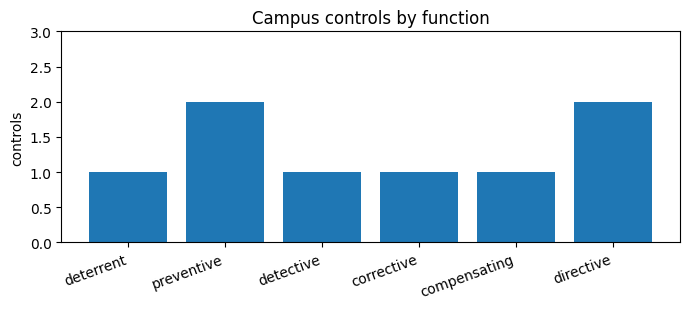

function
deterrent       1
preventive      2
detective       1
corrective      1
compensating    1
directive       2


In [13]:
import matplotlib.pyplot as plt

counts = frame['function'].value_counts().reindex(FUNCTIONS, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(counts.index, counts.values)
ax.set_ylabel('controls')
ax.set_title('Campus controls by function')
ax.set_ylim(0, max(3, int(counts.max()) + 1))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print(counts.to_string())


## Section 5. What to write in the report

Classifying the eight is the easy half. The judgment is the graded half.

1. Name the **one control you found hardest to place**. Say which category and function you
   chose, name the other candidate you nearly chose, and say in two sentences what decided it.
2. **C8 and C6 both end up watching the same kind of activity.** Explain in three sentences why
   they do not have the same function, and what a campus gives up by relying on the one it can
   afford.
3. A campus has all eight of these controls and still loses a staff mailbox to a phishing
   message. **Name the one control function you would add first**, say what a control with that
   function would look like here, and defend the choice in three sentences. Do not name a
   product; name a function and what it would do.

Cite Security+ SY0-701 objective 1.1 for the category and function lists, and the open text,
Trivedi, *Cybersecurity: Theory, Practice, and Ethics*, on security controls.


## Section 6. Save your work before you leave

**In Colab:** File, then Save a copy in GitHub. Choose your `mac246-labs` repository, set the
path to `lab1/MAC246_LAB1_S02_Control_Classification_Colab.ipynb`, and write a commit message.

**In Kali:** save the notebook into the `lab1` folder of your clone, then commit and push with
git, and sign out with `gh auth logout`, or `git credential-cache exit` plus deleting the token
on GitHub if this machine has no `gh`.

Either way, open the commit on github.com afterwards and confirm the notebook is actually
there. Commit at minute 45 even if the classification is unfinished: partial work committed on
time is worth more than complete work that never left the machine.

Screenshots for session 2: `lab1_s02_token.png`, `lab1_s02_controls_chart.png`,
`lab1_s02_checks.png` and `lab1_s02_logout.png`. For session 3: `lab1_s03_token.png`,
`lab1_s03_saved.png` showing your final commit on github.com, and `lab1_s03_logout.png`.
